# Assignment 1 — VIIRS Active Fires in Peru (2012–2024)

**Grupo 3**  
**Integrantes:** _pendiente de completar_

Notebook reproducible para las cinco tareas del Assignment 1. La **Fase 1**
ejecuta únicamente las validaciones piloto con 2024 y las Tareas 1–2.

## 1. Consigna oficial

Fuente normativa: [GitHub issue #9 — Assignment 1](https://github.com/anzonyquispe/GeoAgent/issues/9).

La unidad observada es una **detección VIIRS**, no un incendio único. El VCF es
una línea base de cobertura arbórea correspondiente a 2003.

## 2. Entorno y versiones

Este notebook no instala paquetes. Debe ejecutarse exclusivamente en el entorno
Conda `geoagent312` mediante `conda run -n geoagent312 ...`.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import requests
from IPython.display import display

NOTEBOOK_START = time.perf_counter()

versions = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "geopandas": gpd.__version__,
    "rasterio": rasterio.__version__,
    "folium": folium.__version__,
    "matplotlib": matplotlib.__version__,
    "requests": requests.__version__,
}
assert sys.version_info[:2] == (3, 12), (
    f"Se requiere Python 3.12; se detectó {sys.version.split()[0]}"
)
display(pd.Series(versions, name="versión"))

python                          3.12.13
platform      Windows-11-10.0.26200-SP0
pandas                            3.0.3
geopandas                         1.1.4
rasterio                          1.5.0
folium                           0.20.0
matplotlib                       3.11.0
requests                         2.34.2
Name: versión, dtype: str

## 3. Configuración mediante rutas relativas

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(
        "No se encontró pyproject.toml en el directorio actual ni en sus padres."
    )


REPO_ROOT = find_repo_root()
ASSIGNMENT_DIR = REPO_ROOT / "Assignments" / "Assignment1"
CACHE_DIR = ASSIGNMENT_DIR / "cache_grupo3"
RAW_VIIRS_DIR = CACHE_DIR / "raw" / "viirs"
RAW_VCF_DIR = CACHE_DIR / "raw" / "vcf"
RAW_BOUNDARIES_DIR = CACHE_DIR / "raw" / "boundaries"
INTERIM_DIR = CACHE_DIR / "interim"
MANIFEST_DIR = CACHE_DIR / "manifests"
OUTPUT_DIR = ASSIGNMENT_DIR / "outputs_grupo3"

for directory in (
    RAW_VIIRS_DIR,
    RAW_VCF_DIR,
    RAW_BOUNDARIES_DIR,
    INTERIM_DIR,
    MANIFEST_DIR,
    OUTPUT_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

DOWNLOAD_MANIFEST = MANIFEST_DIR / "downloads.json"
PHASE1_SUMMARY = MANIFEST_DIR / "phase1_summary.json"

print("Raíz del repositorio detectada mediante pyproject.toml:", REPO_ROOT.name)
print("CACHE_DIR:", CACHE_DIR.relative_to(REPO_ROOT))
print("OUTPUT_DIR:", OUTPUT_DIR.relative_to(REPO_ROOT))

Raíz del repositorio detectada mediante pyproject.toml: GeoAgent
CACHE_DIR: Assignments\Assignment1\cache_grupo3
OUTPUT_DIR: Assignments\Assignment1\outputs_grupo3


## 4. Catálogo de fuentes

In [3]:
ISSUE_URL = "https://github.com/anzonyquispe/GeoAgent/issues/9"
VIIRS_2024_URL = (
    "https://firms.modaps.eosdis.nasa.gov/data/country/viirs-snpp/"
    "2024/viirs-snpp_2024_Peru.csv"
)
GADM_L1_URL = (
    "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PER_1.json"
)
GADM_L3_URL = (
    "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PER_3.json"
)
VCF_URL = (
    "https://www.dropbox.com/scl/fi/a3c2tdgb7urvbxrmqjaox/"
    "MOD44B.061_Percent_Tree_Cover_2003Peru.tif"
    "?rlkey=1v8v271e4gn2mnnwhrc3gbp4f&st=qs07al4c&dl=0"
)

PILOT_SOURCES = {
    "viirs_2024": {
        "url": VIIRS_2024_URL,
        "path": RAW_VIIRS_DIR / "viirs-snpp_2024_Peru.csv",
        "kind": "csv",
    },
    "gadm_l1": {
        "url": GADM_L1_URL,
        "path": RAW_BOUNDARIES_DIR / "gadm41_PER_1.json",
        "kind": "json",
    },
    "gadm_l3": {
        "url": GADM_L3_URL,
        "path": RAW_BOUNDARIES_DIR / "gadm41_PER_3.json",
        "kind": "json",
    },
    "vcf_2003": {
        "url": VCF_URL,
        "path": RAW_VCF_DIR / "MOD44B.061_Percent_Tree_Cover_2003Peru.tif",
        "kind": "tif",
    },
}

pd.DataFrame(
    [
        {
            "dataset": name,
            "url": item["url"],
            "ruta_relativa": item["path"].relative_to(REPO_ROOT).as_posix(),
            "tipo": item["kind"],
        }
        for name, item in PILOT_SOURCES.items()
    ]
)

,dataset,url,ruta_relativa,tipo
0,viirs_2024,https://firms.modaps.eosdis.nasa.gov/data/coun...,Assignments/Assignment1/cache_grupo3/raw/viirs...,csv
1,gadm_l1,https://geodata.ucdavis.edu/gadm/gadm4.1/json/...,Assignments/Assignment1/cache_grupo3/raw/bound...,json
2,gadm_l3,https://geodata.ucdavis.edu/gadm/gadm4.1/json/...,Assignments/Assignment1/cache_grupo3/raw/bound...,json
3,vcf_2003,https://www.dropbox.com/scl/fi/a3c2tdgb7urvbxr...,Assignments/Assignment1/cache_grupo3/raw/vcf/M...,tif


## 5. Funciones auxiliares de adquisición y validación

In [4]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _load_manifest(path: Path) -> dict:
    if not path.exists():
        return {"files": {}}
    try:
        data = json.loads(path.read_text(encoding="utf-8"))
    except (json.JSONDecodeError, OSError) as exc:
        raise RuntimeError(f"Manifiesto inválido: {path}: {exc}") from exc
    if not isinstance(data, dict) or not isinstance(data.get("files"), dict):
        raise RuntimeError(f"Estructura de manifiesto inválida: {path}")
    return data


def _write_manifest(path: Path, manifest: dict) -> None:
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    temp.replace(path)


def validate_file_signature(path: Path, expected_kind: str) -> None:
    if not path.is_file() or path.stat().st_size == 0:
        raise RuntimeError(f"Archivo ausente o vacío: {path}")

    with path.open("rb") as stream:
        head = stream.read(8192)
    stripped = head.lstrip()
    lowered = stripped[:512].lower()
    html_markers = (b"<!doctype html", b"<html", b"<head", b"<body")
    if any(lowered.startswith(marker) for marker in html_markers):
        raise RuntimeError(
            f"La descarga parece HTML, no {expected_kind.upper()}: {path}"
        )

    if expected_kind == "csv":
        first_line = head.decode("utf-8-sig", errors="replace").splitlines()[0]
        required = {"latitude", "longitude", "acq_date", "frp"}
        columns = {item.strip() for item in first_line.split(",")}
        if not required.issubset(columns):
            raise RuntimeError(
                f"Cabecera CSV inesperada en {path}; faltan {sorted(required - columns)}"
            )
    elif expected_kind == "json":
        if not stripped.startswith((b"{", b"[")):
            raise RuntimeError(f"Firma JSON inválida: {path}")
    elif expected_kind == "tif":
        classic_tiff = (b"II*\x00", b"MM\x00*")
        big_tiff = (b"II+\x00", b"MM\x00+")
        if not head.startswith(classic_tiff + big_tiff):
            raise RuntimeError(f"Firma TIFF/BigTIFF inválida: {path}")
    else:
        raise ValueError(f"Tipo de archivo no soportado: {expected_kind}")


def download_stream(
    url: str,
    destination: Path,
    expected_kind: str,
    manifest_path: Path = DOWNLOAD_MANIFEST,
    chunk_size: int = 1024 * 1024,
) -> dict:
    destination.parent.mkdir(parents=True, exist_ok=True)
    key = destination.relative_to(REPO_ROOT).as_posix()
    manifest = _load_manifest(manifest_path)
    previous = manifest["files"].get(key)

    if destination.exists():
        validate_file_signature(destination, expected_kind)
        size = destination.stat().st_size
        checksum = sha256_file(destination)
        if (
            previous
            and previous.get("requested_url") == url
            and previous.get("size_bytes") == size
            and previous.get("sha256") == checksum
        ):
            record = dict(previous)
            record["reused"] = True
            record["checked_at_utc"] = datetime.now(timezone.utc).isoformat()
            return record

        record = {
            "requested_url": url,
            "resolved_url": previous.get("resolved_url") if previous else url,
            "downloaded_at_utc": (
                previous.get("downloaded_at_utc")
                if previous
                else datetime.now(timezone.utc).isoformat()
            ),
            "checked_at_utc": datetime.now(timezone.utc).isoformat(),
            "size_bytes": size,
            "sha256": checksum,
            "content_type": previous.get("content_type") if previous else None,
            "reused": True,
        }
        manifest["files"][key] = record
        _write_manifest(manifest_path, manifest)
        return record

    partial = destination.with_suffix(destination.suffix + ".part")
    partial.unlink(missing_ok=True)
    started = time.perf_counter()
    try:
        session = requests.Session()
        response = session.get(
            url,
            stream=True,
            allow_redirects=True,
            timeout=(20, 180),
            headers={"User-Agent": "GeoAgent-Assignment1-Grupo3/1.0"},
        )
        initial_content_type = response.headers.get("Content-Type", "")
        if expected_kind == "tif" and "text/html" in initial_content_type.lower():
            response.close()
            redirect_probe = session.head(
                url,
                allow_redirects=False,
                timeout=(20, 60),
                headers={"User-Agent": "curl/8.14.1"},
            )
            redirect_url = redirect_probe.headers.get("Location")
            redirect_probe.close()
            if not redirect_url:
                raise RuntimeError(
                    "El enlace VCF oficial devolvió HTML y no publicó una "
                    "redirección de contenido en la cabecera HEAD."
                )
            response = session.get(
                redirect_url,
                stream=True,
                allow_redirects=True,
                timeout=(20, 180),
                headers={"User-Agent": "GeoAgent-Assignment1-Grupo3/1.0"},
            )

        with response:
            response.raise_for_status()
            content_type = response.headers.get("Content-Type", "")
            iterator = response.iter_content(chunk_size=chunk_size)
            first_chunk = next(iterator, b"")
            if not first_chunk:
                raise RuntimeError(f"Respuesta vacía al descargar {url}")
            lowered = first_chunk.lstrip()[:512].lower()
            if "text/html" in content_type.lower() or lowered.startswith(
                (b"<!doctype html", b"<html")
            ):
                raise RuntimeError(
                    f"El servidor devolvió HTML ({content_type}) para {url}"
                )
            with partial.open("wb") as stream:
                stream.write(first_chunk)
                for chunk in iterator:
                    if chunk:
                        stream.write(chunk)

            validate_file_signature(partial, expected_kind)
            partial.replace(destination)
            record = {
                "requested_url": url,
                "resolved_url": str(response.url),
                "downloaded_at_utc": datetime.now(timezone.utc).isoformat(),
                "checked_at_utc": datetime.now(timezone.utc).isoformat(),
                "size_bytes": destination.stat().st_size,
                "sha256": sha256_file(destination),
                "content_type": content_type,
                "elapsed_seconds": round(time.perf_counter() - started, 3),
                "reused": False,
            }
    except Exception:
        partial.unlink(missing_ok=True)
        raise

    manifest["files"][key] = record
    _write_manifest(manifest_path, manifest)
    return record

## 6. Adquisición piloto

In [5]:
download_records = {}
for dataset in ("viirs_2024", "gadm_l1", "gadm_l3"):
    source = PILOT_SOURCES[dataset]
    download_records[dataset] = download_stream(
        source["url"], source["path"], source["kind"]
    )

try:
    source = PILOT_SOURCES["vcf_2003"]
    download_records["vcf_2003"] = download_stream(
        source["url"], source["path"], source["kind"]
    )
except Exception as exc:
    manual_instruction = (
        "Descarga manual requerida: abre exclusivamente el enlace VCF del issue #9, "
        "descarga el archivo sin convertirlo ni renombrarlo y guárdalo en "
        f"'{PILOT_SOURCES['vcf_2003']['path'].relative_to(REPO_ROOT).as_posix()}'. "
        "Luego vuelve a ejecutar esta celda. No uses otra fuente."
    )
    raise RuntimeError(f"No fue posible automatizar el VCF: {exc}. {manual_instruction}") from exc

download_table = pd.DataFrame.from_dict(download_records, orient="index")
display(download_table[["size_bytes", "sha256", "content_type", "reused"]])

,size_bytes,sha256,content_type,reused
viirs_2024,7963113,21afe44401c95f7988950c425d23938dbaffd98d392b87...,text/csv,True
gadm_l1,695822,1ae8d736d0307a39169a300539cdac07a2a7d6d91256e3...,application/json,True
gadm_l3,4425168,d684f8b2c8809305672727856d74e399eddf50f63fcdf2...,application/json,True
vcf_2003,32784639,cb5c56e45f332b269c66d0d897f7c5908005d65294aff4...,image/tiff,True


## 7. Validación territorial

In [6]:
departments = gpd.read_file(PILOT_SOURCES["gadm_l1"]["path"])
districts = gpd.read_file(PILOT_SOURCES["gadm_l3"]["path"])

required_l1 = {"GID_1", "NAME_1", "geometry"}
required_l3 = {"GID_3", "GID_1", "NAME_3", "NAME_1", "geometry"}
missing_l1 = required_l1 - set(departments.columns)
missing_l3 = required_l3 - set(districts.columns)
if missing_l1 or missing_l3:
    raise ValueError(
        f"Contrato territorial incumplido: L1 faltan {sorted(missing_l1)}; "
        f"L3 faltan {sorted(missing_l3)}"
    )
if departments.crs is None or districts.crs is None:
    raise ValueError("GADM debe declarar CRS en ambos niveles.")

territorial_qc = {
    "department_rows": int(len(departments)),
    "district_rows": int(len(districts)),
    "department_crs": str(departments.crs),
    "district_crs": str(districts.crs),
    "department_empty": int(departments.geometry.is_empty.sum()),
    "district_empty": int(districts.geometry.is_empty.sum()),
    "department_missing_geometry": int(departments.geometry.isna().sum()),
    "district_missing_geometry": int(districts.geometry.isna().sum()),
    "department_invalid_before": int((~departments.geometry.is_valid).sum()),
    "district_invalid_before": int((~districts.geometry.is_valid).sum()),
    "duplicate_gid1": int(departments["GID_1"].duplicated().sum()),
    "duplicate_gid3": int(districts["GID_3"].duplicated().sum()),
    "district_missing_parent_gid1": int(districts["GID_1"].isna().sum()),
}

if territorial_qc["department_invalid_before"]:
    departments = departments.copy()
    departments["geometry"] = departments.geometry.make_valid()
if territorial_qc["district_invalid_before"]:
    districts = districts.copy()
    districts["geometry"] = districts.geometry.make_valid()

territorial_qc["department_invalid_after"] = int(
    (~departments.geometry.is_valid).sum()
)
territorial_qc["district_invalid_after"] = int(
    (~districts.geometry.is_valid).sum()
)

parent_ids = set(districts["GID_1"].dropna().astype(str))
department_ids = set(departments["GID_1"].dropna().astype(str))
territorial_qc["district_parents_missing_in_l1"] = sorted(
    parent_ids - department_ids
)
territorial_qc["l1_without_l3_districts"] = sorted(department_ids - parent_ids)
territorial_qc["gid3_parent_conflicts"] = int(
    (districts.groupby("GID_3", dropna=False)["GID_1"].nunique() > 1).sum()
)

departments_equal_area = departments.to_crs("EPSG:6933")
districts_equal_area = districts.to_crs("EPSG:6933")
department_union = departments_equal_area.geometry.union_all()
district_union = districts_equal_area.geometry.union_all()
territorial_qc["district_coverage_of_departments"] = float(
    district_union.intersection(department_union).area / department_union.area
)
territorial_qc["district_area_outside_departments"] = float(
    district_union.difference(department_union).area / district_union.area
)
territorial_qc["department_bounds"] = departments.total_bounds.tolist()
territorial_qc["district_bounds"] = districts.total_bounds.tolist()

assert territorial_qc["department_empty"] == 0
assert territorial_qc["district_empty"] == 0
assert territorial_qc["department_missing_geometry"] == 0
assert territorial_qc["district_missing_geometry"] == 0
assert territorial_qc["duplicate_gid1"] == 0
assert territorial_qc["duplicate_gid3"] == 0
assert territorial_qc["district_missing_parent_gid1"] == 0
assert territorial_qc["gid3_parent_conflicts"] == 0
assert not territorial_qc["district_parents_missing_in_l1"]
assert territorial_qc["department_invalid_after"] == 0
assert territorial_qc["district_invalid_after"] == 0
if territorial_qc["district_coverage_of_departments"] < 0.99:
    warnings.warn("La cobertura L3 sobre L1 es inferior a 99%.")

print("Columnas GADM L1:", departments.columns.tolist())
print("Columnas GADM L3:", districts.columns.tolist())
display(pd.Series(territorial_qc, name="valor"))

Columnas GADM L1: ['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']
Columnas GADM L3: ['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NL_NAME_2', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry']


department_rows                                                          26
district_rows                                                          1815
department_crs                                                    EPSG:4326
district_crs                                                      EPSG:4326
department_empty                                                          0
district_empty                                                            0
department_missing_geometry                                               0
district_missing_geometry                                                 0
department_invalid_before                                                 0
district_invalid_before                                                   0
duplicate_gid1                                                            0
duplicate_gid3                                                            0
district_missing_parent_gid1                                              0
department_i

## 8. Validación VIIRS 2024

In [7]:
required_viirs = {
    "latitude",
    "longitude",
    "acq_date",
    "acq_time",
    "satellite",
    "instrument",
    "confidence",
    "frp",
}
fires_2024 = pd.read_csv(
    PILOT_SOURCES["viirs_2024"]["path"],
    dtype={
        "acq_time": "string",
        "satellite": "string",
        "instrument": "string",
        "confidence": "string",
    },
)
missing_viirs = required_viirs - set(fires_2024.columns)
if missing_viirs:
    raise ValueError(f"Faltan columnas VIIRS obligatorias: {sorted(missing_viirs)}")

for numeric_column in ("latitude", "longitude", "frp"):
    fires_2024[numeric_column] = pd.to_numeric(
        fires_2024[numeric_column], errors="coerce"
    )
parsed_dates = pd.to_datetime(fires_2024["acq_date"], errors="coerce")

time_raw = fires_2024["acq_time"].astype("string").str.strip()
time_digits = time_raw.str.fullmatch(r"\d{1,4}", na=False)
time_hhmm = time_raw.str.zfill(4)
hours = pd.to_numeric(time_hhmm.str[:2], errors="coerce")
minutes = pd.to_numeric(time_hhmm.str[2:], errors="coerce")
valid_hhmm = time_digits & hours.between(0, 23) & minutes.between(0, 59)
fires_2024["acq_time_hhmm"] = time_hhmm

confidence_raw = fires_2024["confidence"].astype("string").str.strip().str.lower()
confidence_map = {
    "h": "high",
    "high": "high",
    "n": "nominal",
    "nominal": "nominal",
    "l": "low",
    "low": "low",
}
fires_2024["confidence_raw"] = confidence_raw
fires_2024["confidence_norm"] = confidence_raw.map(confidence_map).astype("string")
unknown_confidence = sorted(
    set(confidence_raw.dropna().unique()) - set(confidence_map)
)

viirs_qc = {
    "rows": int(len(fires_2024)),
    "columns": fires_2024.columns.tolist(),
    "dtypes": {column: str(dtype) for column, dtype in fires_2024.dtypes.items()},
    "date_min": parsed_dates.min().date().isoformat(),
    "date_max": parsed_dates.max().date().isoformat(),
    "invalid_dates": int(parsed_dates.isna().sum()),
    "rows_outside_2024": int((parsed_dates.dt.year != 2024).sum()),
    "invalid_latitude": int(
        (fires_2024["latitude"].isna() | ~fires_2024["latitude"].between(-90, 90)).sum()
    ),
    "invalid_longitude": int(
        (fires_2024["longitude"].isna() | ~fires_2024["longitude"].between(-180, 180)).sum()
    ),
    "invalid_frp": int(
        (fires_2024["frp"].isna() | ~np.isfinite(fires_2024["frp"])).sum()
    ),
    "nonpositive_frp": int((fires_2024["frp"] <= 0).sum()),
    "invalid_acq_time": int((~valid_hhmm).sum()),
    "confidence_counts": confidence_raw.value_counts(dropna=False).to_dict(),
    "unknown_confidence": unknown_confidence,
    "satellite_counts": fires_2024["satellite"].value_counts(dropna=False).to_dict(),
    "instrument_counts": fires_2024["instrument"].value_counts(dropna=False).to_dict(),
    "duplicate_rows": int(fires_2024.duplicated().sum()),
    "null_counts": {
        column: int(count)
        for column, count in fires_2024.isna().sum().items()
        if count
    },
    "latitude_min": float(fires_2024["latitude"].min()),
    "latitude_max": float(fires_2024["latitude"].max()),
    "longitude_min": float(fires_2024["longitude"].min()),
    "longitude_max": float(fires_2024["longitude"].max()),
    "frp_min": float(fires_2024["frp"].min()),
    "frp_max": float(fires_2024["frp"].max()),
}

assert viirs_qc["invalid_dates"] == 0
assert viirs_qc["rows_outside_2024"] == 0
assert viirs_qc["invalid_latitude"] == 0
assert viirs_qc["invalid_longitude"] == 0
assert viirs_qc["invalid_frp"] == 0
assert viirs_qc["invalid_acq_time"] == 0
assert not unknown_confidence
assert fires_2024["confidence_norm"].notna().all()

print("Esquema VIIRS 2024 original:", [c for c in fires_2024.columns if c not in {"acq_time_hhmm", "confidence_raw", "confidence_norm"}])
display(pd.Series(viirs_qc, name="valor"))

Esquema VIIRS 2024 original: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type']


rows                                                              99932
columns               [latitude, longitude, bright_ti4, scan, track,...
dtypes                {'latitude': 'float64', 'longitude': 'float64'...
date_min                                                     2024-01-01
date_max                                                     2024-12-31
invalid_dates                                                         0
rows_outside_2024                                                     0
invalid_latitude                                                      0
invalid_longitude                                                     0
invalid_frp                                                           0
nonpositive_frp                                                       0
invalid_acq_time                                                      0
confidence_counts                    {'n': 88096, 'l': 6723, 'h': 5113}
unknown_confidence                                              

## 9. Validación VCF 2003

In [8]:
vcf_path = PILOT_SOURCES["vcf_2003"]["path"]
valid_pixels = 0
masked_pixels = 0
vcf_min = None
vcf_max = None

with rasterio.open(vcf_path) as src:
    if src.count != 1:
        raise ValueError(f"El VCF debe tener una banda; se detectaron {src.count}.")
    if src.crs is None:
        raise ValueError("El VCF no declara CRS.")

    for _, window in src.block_windows(1):
        block = src.read(1, window=window, masked=True)
        valid = block.compressed()
        valid_pixels += int(valid.size)
        masked_pixels += int(block.size - valid.size)
        if valid.size:
            block_min = float(valid.min())
            block_max = float(valid.max())
            vcf_min = block_min if vcf_min is None else min(vcf_min, block_min)
            vcf_max = block_max if vcf_max is None else max(vcf_max, block_max)

    dtype = np.dtype(src.dtypes[0])
    band_uncompressed_bytes = int(src.width * src.height * dtype.itemsize)
    mask_estimated_bytes = int(src.width * src.height)
    vcf_qc = {
        "driver": src.driver,
        "band_count": int(src.count),
        "crs": str(src.crs),
        "width": int(src.width),
        "height": int(src.height),
        "resolution": [float(abs(src.res[0])), float(abs(src.res[1]))],
        "dtype": str(dtype),
        "nodata": None if src.nodata is None else float(src.nodata),
        "mask_flags": [str(flag) for flag in src.mask_flag_enums[0]],
        "block_shape": list(src.block_shapes[0]),
        "compression": src.profile.get("compress"),
        "valid_pixels": valid_pixels,
        "masked_pixels": masked_pixels,
        "valid_min": vcf_min,
        "valid_max": vcf_max,
        "band_uncompressed_bytes": band_uncompressed_bytes,
        "mask_estimated_bytes": mask_estimated_bytes,
        "file_size_bytes": vcf_path.stat().st_size,
    }

if valid_pixels == 0:
    raise ValueError("El VCF no contiene píxeles válidos.")
display(pd.Series(vcf_qc, name="valor"))

driver                                                                 GTiff
band_count                                                                 1
crs                        PROJCS["unknown",GEOGCS["unknown",DATUM["unkno...
width                                                                   8480
height                                                                  9012
resolution                                  [231.6563582625, 231.6563582625]
dtype                                                                  uint8
nodata                                                                 253.0
mask_flags                                                               [8]
block_shape                                                       [512, 512]
compression                                                              lzw
valid_pixels                                                        59235695
masked_pixels                                                       17186065

## 10. Tarea 1 — Coropleta estática por distrito

Se realiza point-in-polygon en CRS consistente, se conservan todos los
distritos y se completan con cero aquellos sin detecciones.

In [9]:
valid_points = fires_2024[
    fires_2024["latitude"].between(-90, 90)
    & fires_2024["longitude"].between(-180, 180)
].copy()
fires_points = gpd.GeoDataFrame(
    valid_points,
    geometry=gpd.points_from_xy(valid_points["longitude"], valid_points["latitude"]),
    crs="EPSG:4326",
)
districts_join = districts.to_crs(fires_points.crs)
join_columns = ["GID_3", "GID_1", "NAME_3", "NAME_1", "geometry"]
assigned = gpd.sjoin(
    fires_points,
    districts_join[join_columns],
    how="left",
    predicate="within",
)
raw_matches = assigned.dropna(subset=["GID_3"]).copy()
matches_per_point = raw_matches.groupby(level=0).size()
conflict_indices = matches_per_point[matches_per_point > 1].index
overlap_conflict_points = int(len(conflict_indices))
overlap_extra_matches = int((matches_per_point - 1).clip(lower=0).sum())

# GADM L3 contiene pequeños solapamientos. Como dos polígonos del mismo
# nivel no ofrecen una prioridad semántica, los puntos ambiguos se excluyen
# en vez de asignarlos arbitrariamente o contarlos dos veces.
matched = raw_matches.loc[~raw_matches.index.isin(conflict_indices)].copy()
unmatched_no_polygon = int(
    len(fires_points) - raw_matches.index.nunique()
)
district_counts = matched.groupby("GID_3").size().rename("detecciones_2024")
district_map = districts.merge(district_counts, on="GID_3", how="left")
district_map["detecciones_2024"] = (
    district_map["detecciones_2024"].fillna(0).astype("int64")
)

map_sum = int(district_map["detecciones_2024"].sum())
assigned_count = int(len(matched))
if map_sum != assigned_count:
    raise AssertionError(
        f"Conservación incumplida: mapa={map_sum}, asignados={assigned_count}"
    )

tarea1_output = OUTPUT_DIR / "tarea1_mapa_incendios_2024.png"
tarea1_hash_before = sha256_file(tarea1_output) if tarea1_output.exists() else None
fig, ax = plt.subplots(figsize=(11, 14))
district_map.plot(
    column="detecciones_2024",
    cmap="OrRd",
    linewidth=0.12,
    edgecolor="#8a8a8a",
    legend=True,
    legend_kwds={"label": "Detecciones VIIRS 2024", "shrink": 0.65},
    ax=ax,
)
departments.to_crs(district_map.crs).boundary.plot(
    ax=ax, color="#303030", linewidth=0.55
)
ax.set_title(
    "Perú: detecciones de incendios VIIRS por distrito, 2024",
    fontsize=15,
    pad=14,
)
ax.set_axis_off()
fig.text(
    0.5,
    0.04,
    "Fuente: NASA FIRMS VIIRS-SNPP; límites provisionales GADM 4.1",
    ha="center",
    fontsize=9,
)
if tarea1_hash_before is None:
    fig.savefig(tarea1_output, dpi=220, bbox_inches="tight", facecolor="white")
plt.close(fig)
tarea1_hash_after = sha256_file(tarea1_output)
if tarea1_hash_before is not None and tarea1_hash_after != tarea1_hash_before:
    raise AssertionError("La salida PNG de Tarea 1 cambió durante la Fase 2.")

task1_qc = {
    "input_points": int(len(fires_points)),
    "assigned_points": assigned_count,
    "unassigned_no_polygon": unmatched_no_polygon,
    "overlap_conflict_points_excluded": overlap_conflict_points,
    "overlap_extra_matches": overlap_extra_matches,
    "unassigned_total": unmatched_no_polygon + overlap_conflict_points,
    "districts_total": int(len(district_map)),
    "districts_with_zero": int((district_map["detecciones_2024"] == 0).sum()),
    "map_sum": map_sum,
    "output": tarea1_output.relative_to(REPO_ROOT).as_posix(),
    "output_sha256": tarea1_hash_after,
    "output_preserved": tarea1_hash_before in (None, tarea1_hash_after),
}
display(pd.Series(task1_qc, name="valor"))

input_points                                                                    99932
assigned_points                                                                 99717
unassigned_no_polygon                                                             187
overlap_conflict_points_excluded                                                   28
overlap_extra_matches                                                              28
unassigned_total                                                                  215
districts_total                                                                  1815
districts_with_zero                                                               316
map_sum                                                                         99717
output                              Assignments/Assignment1/outputs_grupo3/tarea1_...
output_sha256                       f7557f6a1c46a09e061aaa39b2f4f4c8e5cc935112dcae...
output_preserved                                      

## 11. Tarea 2 — Top 100 FRP en mapa dinámico

Se usa `folium.Circle`. Para conservar proporcionalidad estricta se define una
única constante para todos los puntos:

`radio_m = FRP_RADIUS_M_PER_MW × frp`

La constante se calibra para que el mayor FRP tenga un radio de 25 km. No se
suma un radio mínimo.

In [10]:
fire_candidates = fires_2024[
    fires_2024["latitude"].between(-90, 90)
    & fires_2024["longitude"].between(-180, 180)
    & fires_2024["frp"].notna()
    & np.isfinite(fires_2024["frp"])
    & (fires_2024["frp"] > 0)
].copy()
if len(fire_candidates) < 100:
    raise ValueError(f"Solo hay {len(fire_candidates)} candidatos válidos; se requieren 100.")

top100 = fire_candidates.sort_values(
    ["frp", "acq_date", "acq_time_hhmm"],
    ascending=[False, True, True],
    kind="mergesort",
).head(100).copy()

TARGET_MAX_RADIUS_M = 25_000.0
FRP_RADIUS_M_PER_MW = TARGET_MAX_RADIUS_M / float(top100["frp"].max())
top100["radius_m"] = top100["frp"] * FRP_RADIUS_M_PER_MW

if len(top100) != 100:
    raise AssertionError("La selección Top 100 no contiene exactamente 100 filas.")
if not np.allclose(
    top100["radius_m"] / top100["frp"], FRP_RADIUS_M_PER_MW
):
    raise AssertionError("El radio no es estrictamente proporcional a FRP.")

fire_map = folium.Map(
    location=[float(top100["latitude"].mean()), float(top100["longitude"].mean())],
    zoom_start=5,
    tiles="CartoDB positron",
    control_scale=True,
)
for row in top100.itertuples(index=False):
    popup = folium.Popup(
        (
            f"<b>Fecha:</b> {row.acq_date}<br>"
            f"<b>Hora HHMM:</b> {row.acq_time_hhmm}<br>"
            f"<b>FRP:</b> {row.frp:.2f} MW<br>"
            f"<b>Confidence:</b> {row.confidence_raw} ({row.confidence_norm})"
        ),
        max_width=280,
    )
    folium.Circle(
        location=[row.latitude, row.longitude],
        radius=float(row.radius_m),
        color="#b91c1c",
        weight=1,
        fill=True,
        fill_color="#ef4444",
        fill_opacity=0.35,
        popup=popup,
        tooltip=f"FRP {row.frp:.2f} MW",
    ).add_to(fire_map)

fire_map.fit_bounds(
    [
        [float(top100["latitude"].min()), float(top100["longitude"].min())],
        [float(top100["latitude"].max()), float(top100["longitude"].max())],
    ]
)
tarea2_output = OUTPUT_DIR / "tarea2_top100_incendios_2024.html"
tarea2_hash_before = sha256_file(tarea2_output) if tarea2_output.exists() else None
if tarea2_hash_before is None:
    fire_map.save(tarea2_output)
tarea2_hash_after = sha256_file(tarea2_output)
if tarea2_hash_before is not None and tarea2_hash_after != tarea2_hash_before:
    raise AssertionError("La salida HTML de Tarea 2 cambió durante la Fase 2.")

task2_qc = {
    "top_n": int(len(top100)),
    "frp_min_top100": float(top100["frp"].min()),
    "frp_max_top100": float(top100["frp"].max()),
    "radius_constant_m_per_mw": float(FRP_RADIUS_M_PER_MW),
    "radius_min_m": float(top100["radius_m"].min()),
    "radius_max_m": float(top100["radius_m"].max()),
    "strictly_proportional": True,
    "output": tarea2_output.relative_to(REPO_ROOT).as_posix(),
    "output_sha256": tarea2_hash_after,
    "output_preserved": tarea2_hash_before in (None, tarea2_hash_after),
}
display(pd.Series(task2_qc, name="valor"))

top_n                                                                     100
frp_min_top100                                                         204.06
frp_max_top100                                                          645.8
radius_constant_m_per_mw                                            38.711675
radius_min_m                                                      7899.504491
radius_max_m                                                          25000.0
strictly_proportional                                                    True
output                      Assignments/Assignment1/outputs_grupo3/tarea2_...
output_sha256               fef41ee58898e9039df9fe519f2f130662f236f938a6b7...
output_preserved                                                         True
Name: valor, dtype: object

## 12. Tarea 3 — Media VCF 2003 por distrito

El VCF original usa los códigos oficiales:

- `0–100`: porcentaje válido de cobertura arbórea;
- `200`: agua;
- `253`: fill/fuera de la proyección.

Para el análisis se genera un GeoTIFF derivado, alineado con el original,
donde únicamente `0–100` permanece válido y los códigos `200/253` se
convierten a nodata `255`. El GeoTIFF original nunca se modifica.

### 12.1 Preparación reproducible del VCF por bloques

In [11]:
from threading import Event, Thread

import psutil
from pyproj import Transformer
from rasterstats import zonal_stats


def rss_mb() -> float:
    return psutil.Process(os.getpid()).memory_info().rss / (1024**2)


class RSSMonitor:
    """Muestreo aproximado del RSS del kernel durante varias celdas."""

    def __init__(self, interval_seconds: float = 0.05):
        self.interval_seconds = interval_seconds
        self.initial_mb = rss_mb()
        self.peak_mb = self.initial_mb
        self.final_mb = self.initial_mb
        self._stop = Event()
        self._thread = Thread(target=self._sample, daemon=True)

    def _sample(self) -> None:
        while not self._stop.wait(self.interval_seconds):
            self.peak_mb = max(self.peak_mb, rss_mb())

    def start(self):
        self._thread.start()
        return self

    def stop(self):
        self.final_mb = rss_mb()
        self.peak_mb = max(self.peak_mb, self.final_mb)
        self._stop.set()
        self._thread.join(timeout=2)
        return self


phase2_memory_monitor = RSSMonitor().start()
PHASE2_SUMMARY = MANIFEST_DIR / "phase2_summary.json"
VCF_ANALYSIS_PATH = (
    RAW_VCF_DIR / "MOD44B.061_Percent_Tree_Cover_2003Peru_valid_0_100.tif"
)
DISTRICT_STATS_PATH = INTERIM_DIR / "district_vcf_stats_2003.parquet"
FIRES_2024_PARQUET = INTERIM_DIR / "fires_vcf_gt50_2024.parquet"


def histogram_uint8_by_blocks(path: Path) -> tuple[np.ndarray, dict]:
    histogram = np.zeros(256, dtype=np.int64)
    with rasterio.open(path) as src:
        if src.count != 1 or np.dtype(src.dtypes[0]) != np.dtype("uint8"):
            raise ValueError("El VCF debe ser single-band uint8.")
        metadata = {
            "driver": src.driver,
            "crs": str(src.crs),
            "transform": tuple(src.transform),
            "width": int(src.width),
            "height": int(src.height),
            "resolution": [float(abs(src.res[0])), float(abs(src.res[1]))],
            "dtype": src.dtypes[0],
            "nodata": None if src.nodata is None else int(src.nodata),
            "block_shape": list(src.block_shapes[0]),
        }
        for _, window in src.block_windows(1):
            values = src.read(1, window=window, masked=False)
            histogram += np.bincount(values.ravel(), minlength=256)
    return histogram, metadata


raster_prep_start = time.perf_counter()
original_histogram, original_vcf_metadata = histogram_uint8_by_blocks(vcf_path)
allowed_codes = set(range(101)) | {200, 253}
unexpected_codes = {
    int(code): int(original_histogram[code])
    for code in np.flatnonzero(original_histogram)
    if int(code) not in allowed_codes
}
original_code_counts = {
    "valid_0_100": int(original_histogram[:101].sum()),
    "water_200": int(original_histogram[200]),
    "fill_253": int(original_histogram[253]),
    "value_255": int(original_histogram[255]),
    "unexpected_total": int(sum(unexpected_codes.values())),
    "unexpected_codes": unexpected_codes,
    "total_pixels": int(original_histogram.sum()),
}
if original_code_counts["value_255"] != 0:
    raise ValueError(
        "El valor 255 aparece en el VCF original; no puede reutilizarse como nodata."
    )
if unexpected_codes:
    raise ValueError(f"Códigos VCF inesperados: {unexpected_codes}")

derived_reused = VCF_ANALYSIS_PATH.exists()
if not derived_reused:
    temporary_derived = VCF_ANALYSIS_PATH.with_name(
        VCF_ANALYSIS_PATH.stem + ".tmp.tif"
    )
    temporary_derived.unlink(missing_ok=True)
    with rasterio.open(vcf_path) as src:
        profile = src.profile.copy()
        block_height, block_width = src.block_shapes[0]
        profile.update(
            dtype="uint8",
            count=1,
            nodata=255,
            compress="lzw",
            tiled=True,
            blockxsize=int(block_width),
            blockysize=int(block_height),
            BIGTIFF="IF_SAFER",
        )
        with rasterio.open(temporary_derived, "w", **profile) as dst:
            for _, window in src.block_windows(1):
                values = src.read(1, window=window, masked=False)
                valid = values <= 100
                output = np.where(valid, values, 255).astype("uint8")
                dst.write(output, 1, window=window)
    temporary_derived.replace(VCF_ANALYSIS_PATH)

derived_histogram, derived_vcf_metadata = histogram_uint8_by_blocks(
    VCF_ANALYSIS_PATH
)
derived_unexpected = {
    int(code): int(derived_histogram[code])
    for code in np.flatnonzero(derived_histogram)
    if not (0 <= int(code) <= 100 or int(code) == 255)
}
if derived_unexpected:
    raise ValueError(f"El VCF derivado contiene códigos inesperados: {derived_unexpected}")
if int(derived_histogram[:101].sum()) != original_code_counts["valid_0_100"]:
    raise AssertionError("El conteo válido cambió al crear el VCF derivado.")
expected_derived_nodata = (
    original_code_counts["water_200"] + original_code_counts["fill_253"]
)
if int(derived_histogram[255]) != expected_derived_nodata:
    raise AssertionError("El nodata derivado no equivale a agua + fill.")

with rasterio.open(vcf_path) as original, rasterio.open(
    VCF_ANALYSIS_PATH
) as derived:
    alignment_checks = {
        "same_crs": original.crs == derived.crs,
        "same_transform": original.transform == derived.transform,
        "same_dimensions": (
            original.width == derived.width and original.height == derived.height
        ),
        "same_resolution": original.res == derived.res,
        "derived_dtype_uint8": derived.dtypes[0] == "uint8",
        "derived_nodata_255": derived.nodata == 255,
        "single_band": derived.count == 1,
    }
    if not all(alignment_checks.values()):
        raise AssertionError(f"Desalineación del VCF derivado: {alignment_checks}")

raster_prep_seconds = time.perf_counter() - raster_prep_start
vcf_derived_qc = {
    "path": VCF_ANALYSIS_PATH.relative_to(REPO_ROOT).as_posix(),
    "reused": derived_reused,
    "file_size_bytes": VCF_ANALYSIS_PATH.stat().st_size,
    "sha256": sha256_file(VCF_ANALYSIS_PATH),
    "creation_and_validation_seconds": round(raster_prep_seconds, 3),
    "original_counts": original_code_counts,
    "derived_valid_0_100": int(derived_histogram[:101].sum()),
    "derived_nodata_255": int(derived_histogram[255]),
    "derived_unexpected": derived_unexpected,
    "metadata": derived_vcf_metadata,
    "alignment_checks": alignment_checks,
}
display(pd.Series(vcf_derived_qc, name="valor"))

<archivo-temporal-del-kernel>.py:65: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  values = src.read(1, window=window, masked=False)


<archivo-temporal-del-kernel>.py:115: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  values = src.read(1, window=window, masked=False)


path                               Assignments/Assignment1/cache_grupo3/raw/vcf/M...
reused                                                                         False
file_size_bytes                                                             23668022
sha256                             4c24f6f493c6c6e7b5cafe9285ee4902972f1630747831...
creation_and_validation_seconds                                                2.172
original_counts                    {'valid_0_100': 43073779, 'water_200': 1616191...
derived_valid_0_100                                                         43073779
derived_nodata_255                                                          33347981
derived_unexpected                                                                {}
metadata                           {'driver': 'GTiff', 'crs': 'PROJCS["unknown",G...
alignment_checks                   {'same_crs': True, 'same_transform': True, 'sa...
Name: valor, dtype: object

### 12.2 Estadística zonal distrital

In [12]:
task3_start = time.perf_counter()

required_task3_columns = {"GID_3", "GID_1", "NAME_3", "NAME_1", "geometry"}
missing_task3_columns = required_task3_columns - set(districts.columns)
if missing_task3_columns:
    raise ValueError(
        f"Faltan columnas territoriales: {sorted(missing_task3_columns)}"
    )
task3_territorial_checks = {
    "districts_total": int(len(districts)),
    "crs_present": districts.crs is not None,
    "empty_geometry": int(districts.geometry.is_empty.sum()),
    "missing_geometry": int(districts.geometry.isna().sum()),
    "invalid_geometry": int((~districts.geometry.is_valid).sum()),
    "duplicate_gid3": int(districts["GID_3"].duplicated().sum()),
    "missing_gid1": int(districts["GID_1"].isna().sum()),
    "gid3_parent_conflicts": int(
        (districts.groupby("GID_3")["GID_1"].nunique() > 1).sum()
    ),
}
if len(districts) != 1815:
    raise AssertionError(f"Se esperaban 1,815 distritos; hay {len(districts)}.")
if not task3_territorial_checks["crs_present"]:
    raise ValueError("Los distritos no declaran CRS.")
if any(
    task3_territorial_checks[key]
    for key in (
        "empty_geometry",
        "missing_geometry",
        "invalid_geometry",
        "duplicate_gid3",
        "missing_gid1",
        "gid3_parent_conflicts",
    )
):
    raise ValueError(
        f"Falló la validación territorial: {task3_territorial_checks}"
    )

with rasterio.open(VCF_ANALYSIS_PATH) as src:
    vcf_analysis_crs = src.crs
    if src.nodata != 255:
        raise ValueError("El VCF derivado debe declarar nodata=255.")
districts_vcf_crs = districts.to_crs(vcf_analysis_crs)

zonal_results = zonal_stats(
    districts_vcf_crs.geometry,
    VCF_ANALYSIS_PATH,
    stats=["mean", "count"],
    nodata=255,
    all_touched=False,
)
district_vcf_stats = districts[
    ["GID_3", "GID_1", "NAME_3", "NAME_1", "geometry"]
].copy()
district_vcf_stats["mean_vcf"] = pd.to_numeric(
    [result.get("mean") for result in zonal_results], errors="coerce"
)
district_vcf_stats["valid_pixel_count"] = pd.Series(
    [result.get("count", 0) for result in zonal_results], dtype="int64"
)
valid_district_mask = (
    (district_vcf_stats["valid_pixel_count"] > 0)
    & np.isfinite(district_vcf_stats["mean_vcf"])
)
median_vcf = float(
    district_vcf_stats.loc[valid_district_mask, "mean_vcf"].median()
)
district_vcf_stats["selected_above_median"] = (
    valid_district_mask & (district_vcf_stats["mean_vcf"] > median_vcf)
)

valid_means = district_vcf_stats.loc[valid_district_mask, "mean_vcf"]
if not valid_means.between(0, 100).all():
    raise AssertionError("Hay medias fuera del rango válido 0–100.")
if derived_histogram[200] != 0 or derived_histogram[253] != 0:
    raise AssertionError("Los códigos 200/253 aparecen en el VCF analítico.")

district_vcf_stats.to_parquet(
    DISTRICT_STATS_PATH, index=False, compression="snappy"
)
task3_seconds = time.perf_counter() - task3_start
task3_summary = {
    "districts_total": int(len(district_vcf_stats)),
    "districts_valid": int(valid_district_mask.sum()),
    "districts_without_valid_pixels": int((~valid_district_mask).sum()),
    "median_vcf": median_vcf,
    "districts_selected": int(
        district_vcf_stats["selected_above_median"].sum()
    ),
    "selected_pct_total": float(
        100 * district_vcf_stats["selected_above_median"].mean()
    ),
    "selected_pct_valid": float(
        100
        * district_vcf_stats["selected_above_median"].sum()
        / valid_district_mask.sum()
    ),
    "mean_vcf_min": float(valid_means.min()),
    "mean_vcf_max": float(valid_means.max()),
    "mean_vcf_average": float(valid_means.mean()),
    "all_touched": False,
    "water_200_excluded": bool(derived_histogram[200] == 0),
    "fill_253_excluded": bool(derived_histogram[253] == 0),
    "elapsed_seconds": round(task3_seconds, 3),
    "stats_path": DISTRICT_STATS_PATH.relative_to(REPO_ROOT).as_posix(),
    "stats_size_bytes": DISTRICT_STATS_PATH.stat().st_size,
}
display(pd.Series(task3_summary, name="valor"))
display(
    district_vcf_stats[
        [
            "GID_3",
            "GID_1",
            "NAME_3",
            "NAME_1",
            "mean_vcf",
            "valid_pixel_count",
            "selected_above_median",
        ]
    ].head()
)

districts_total                                                                1815
districts_valid                                                                1814
districts_without_valid_pixels                                                    1
median_vcf                                                                 6.473076
districts_selected                                                              907
selected_pct_total                                                        49.972452
selected_pct_valid                                                             50.0
mean_vcf_min                                                               0.032258
mean_vcf_max                                                              78.915629
mean_vcf_average                                                           14.43594
all_touched                                                                   False
water_200_excluded                                                          

,GID_3,GID_1,NAME_3,NAME_1,mean_vcf,valid_pixel_count,selected_above_median
0,PER.1.1.1_1,PER.1_1,Aramango,Amazonas,44.669878,15676,True
1,PER.1.1.2_1,PER.1_1,Copallin,Amazonas,19.574608,1977,True
2,PER.1.1.3_1,PER.1_1,ElParco,Amazonas,16.443548,248,True
3,PER.1.1.4_1,PER.1_1,Imaza,Amazonas,63.563301,87202,True
4,PER.1.1.5_1,PER.1_1,LaPeca,Amazonas,21.072742,4839,True


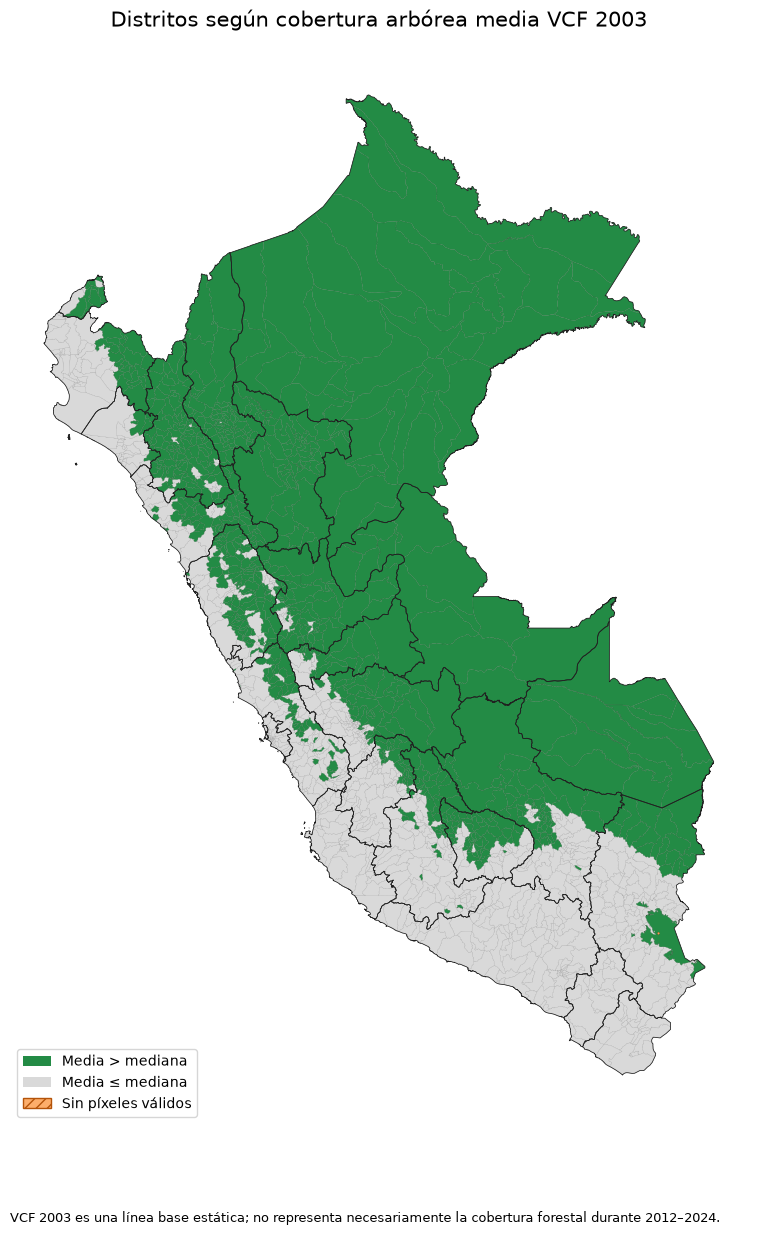

In [13]:
from matplotlib.patches import Patch

valid_not_selected = valid_district_mask & ~district_vcf_stats[
    "selected_above_median"
]
no_data_mask = ~valid_district_mask

fig, ax = plt.subplots(figsize=(11, 14))
district_vcf_stats.loc[valid_not_selected].plot(
    ax=ax, color="#d9d9d9", edgecolor="#8c8c8c", linewidth=0.12
)
district_vcf_stats.loc[
    district_vcf_stats["selected_above_median"]
].plot(ax=ax, color="#238b45", edgecolor="#35603f", linewidth=0.15)
if no_data_mask.any():
    district_vcf_stats.loc[no_data_mask].plot(
        ax=ax,
        color="#fdae6b",
        edgecolor="#b45309",
        linewidth=0.3,
        hatch="///",
    )
departments.to_crs(district_vcf_stats.crs).boundary.plot(
    ax=ax, color="#202020", linewidth=0.55
)
legend_handles = [
    Patch(facecolor="#238b45", label="Media > mediana"),
    Patch(facecolor="#d9d9d9", label="Media ≤ mediana"),
]
if no_data_mask.any():
    legend_handles.append(
        Patch(
            facecolor="#fdae6b",
            edgecolor="#b45309",
            hatch="///",
            label="Sin píxeles válidos",
        )
    )
ax.legend(handles=legend_handles, loc="lower left", frameon=True)
ax.set_title(
    "Distritos según cobertura arbórea media VCF 2003",
    fontsize=15,
    pad=14,
)
ax.set_axis_off()
fig.text(
    0.5,
    0.04,
    (
        "VCF 2003 es una línea base estática; no representa necesariamente "
        "la cobertura forestal durante 2012–2024."
    ),
    ha="center",
    fontsize=9,
)
plt.show()

## 13. Tarea 4 — Piloto VIIRS 2024 con `rasterio.sample`

El piloto parte de las 99,932 detecciones originales, conserva solo las
99,717 asignaciones distritales unívocas y filtra primero los distritos
seleccionados en la Tarea 3. Los 28 casos ambiguos y los puntos sin distrito
permanecen excluidos.

Para mantener el diagnóstico de códigos `200` y `253`, el muestreo se realiza
sobre el VCF original con `masked=False`. La validez se decide explícitamente:
`50 < vcf_value <= 100`. El código 253 coincide con el nodata declarado del
archivo original, por lo que ambos conteos se reportan, pero no son categorías
aditivas independientes.

### 13.1 Funciones y conjunto candidato

In [14]:
TASK4_REQUIRED_COLUMNS = [
    "latitude",
    "longitude",
    "acq_date",
    "acq_time",
    "satellite",
    "instrument",
    "confidence",
    "frp",
    "GID_3",
    "GID_1",
    "NAME_3",
    "NAME_1",
    "vcf_value",
    "year",
    "source_index",
    "detection_id",
]


def canonical_result(data: pd.DataFrame) -> pd.DataFrame:
    return (
        data[TASK4_REQUIRED_COLUMNS]
        .sort_values("detection_id", kind="mergesort")
        .reset_index(drop=True)
    )


def canonical_result_hash(data: pd.DataFrame) -> str:
    ordered = canonical_result(data)
    payload = ordered.to_csv(
        index=False, lineterminator="\n", float_format="%.12g"
    ).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def sample_vcf_in_chunks(
    points: pd.DataFrame,
    raster_path: Path,
    chunk_size: int,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    if chunk_size <= 0:
        raise ValueError("chunk_size debe ser positivo.")
    processed = points.copy().reset_index(drop=True)
    total = len(processed)
    transformed_x = np.full(total, np.nan, dtype="float64")
    transformed_y = np.full(total, np.nan, dtype="float64")
    rows = np.full(total, -1, dtype="int64")
    cols = np.full(total, -1, dtype="int64")
    in_bounds = np.zeros(total, dtype=bool)
    sampled_values = np.full(total, -1, dtype="int16")

    with rasterio.open(raster_path) as src:
        if src.count != 1 or src.dtypes[0] != "uint8":
            raise ValueError("El VCF de muestreo debe ser single-band uint8.")
        if src.nodata != 253:
            raise ValueError(f"Se esperaba nodata=253; se encontró {src.nodata}.")
        transformer = Transformer.from_crs(
            "EPSG:4326", src.crs, always_xy=True
        )
        for start in range(0, total, chunk_size):
            stop = min(start + chunk_size, total)
            longitude = processed["longitude"].iloc[start:stop].to_numpy()
            latitude = processed["latitude"].iloc[start:stop].to_numpy()
            x_values, y_values = transformer.transform(longitude, latitude)
            x_values = np.asarray(x_values, dtype="float64")
            y_values = np.asarray(y_values, dtype="float64")
            row_values, col_values = rasterio.transform.rowcol(
                src.transform, x_values, y_values, op=np.floor
            )
            row_values = np.asarray(row_values, dtype="int64")
            col_values = np.asarray(col_values, dtype="int64")
            inside = (
                (row_values >= 0)
                & (row_values < src.height)
                & (col_values >= 0)
                & (col_values < src.width)
            )

            transformed_x[start:stop] = x_values
            transformed_y[start:stop] = y_values
            rows[start:stop] = row_values
            cols[start:stop] = col_values
            in_bounds[start:stop] = inside

            local_positions = np.flatnonzero(inside)
            if local_positions.size:
                coordinates = zip(
                    x_values[local_positions], y_values[local_positions]
                )
                values = np.fromiter(
                    (
                        int(sample[0])
                        for sample in src.sample(
                            coordinates, indexes=1, masked=False
                        )
                    ),
                    dtype="int16",
                    count=int(local_positions.size),
                )
                sampled_values[start + local_positions] = values

        nodata_value = int(src.nodata)

    value_objects = np.empty(total, dtype=object)
    value_objects[:] = pd.NA
    value_objects[in_bounds] = sampled_values[in_bounds].astype(int)
    processed["vcf_x"] = transformed_x
    processed["vcf_y"] = transformed_y
    processed["raster_row"] = rows
    processed["raster_col"] = cols
    processed["in_raster_bounds"] = in_bounds
    processed["vcf_value"] = pd.array(value_objects, dtype="Int16")

    inside_values = sampled_values[in_bounds]
    valid_values = (inside_values >= 0) & (inside_values <= 100)
    water_values = inside_values == 200
    fill_values = inside_values == 253
    unexpected_values = ~(
        valid_values | water_values | fill_values
    )
    unexpected_codes = {
        int(code): int((inside_values == code).sum())
        for code in np.unique(inside_values[unexpected_values])
    }
    if unexpected_codes:
        raise ValueError(
            f"El muestreo encontró códigos VCF inesperados: {unexpected_codes}"
        )

    final_mask = (
        processed["in_raster_bounds"]
        & processed["vcf_value"].notna()
        & (processed["vcf_value"] > 50)
        & (processed["vcf_value"] <= 100)
    )
    final = processed.loc[final_mask, TASK4_REQUIRED_COLUMNS].copy()
    final["vcf_value"] = final["vcf_value"].astype("uint8")
    final["year"] = final["year"].astype("int16")

    qc = {
        "chunk_size": int(chunk_size),
        "candidate_points": int(total),
        "inside_bounds": int(in_bounds.sum()),
        "outside_bounds": int((~in_bounds).sum()),
        "valid_0_100": int(valid_values.sum()),
        "code_200": int(water_values.sum()),
        "code_253": int(fill_values.sum()),
        "nodata": int((inside_values == nodata_value).sum()),
        "unexpected": int(unexpected_values.sum()),
        "unexpected_codes": unexpected_codes,
        "final_gt50_le100": int(len(final)),
    }
    if qc["candidate_points"] != qc["inside_bounds"] + qc["outside_bounds"]:
        raise AssertionError("Falló la conservación de bounds.")
    if qc["inside_bounds"] != (
        qc["valid_0_100"]
        + qc["code_200"]
        + qc["code_253"]
        + qc["unexpected"]
    ):
        raise AssertionError("Falló la clasificación de valores VCF.")
    if qc["nodata"] != qc["code_253"]:
        raise AssertionError("El nodata original debe coincidir con el código 253.")
    return processed, final, qc


selected_gid3 = set(
    district_vcf_stats.loc[
        district_vcf_stats["selected_above_median"], "GID_3"
    ]
)
if len(fires_2024) != 99_932:
    raise AssertionError(f"VIIRS 2024 cambió: {len(fires_2024)} filas.")
if len(matched) != 99_717:
    raise AssertionError(f"Las asignaciones unívocas cambiaron: {len(matched)}.")
if overlap_conflict_points != 28 or unmatched_no_polygon != 187:
    raise AssertionError(
        "Los conteos de ambigüedad/sin distrito cambiaron respecto a Fase 1."
    )

candidate_columns = [
    "latitude",
    "longitude",
    "acq_date",
    "acq_time",
    "satellite",
    "instrument",
    "confidence",
    "frp",
    "GID_3",
    "GID_1",
    "NAME_3",
    "NAME_1",
]
task4_candidates = matched.loc[
    matched["GID_3"].isin(selected_gid3), candidate_columns
].copy()
task4_candidates["source_index"] = task4_candidates.index.astype("int64")
task4_candidates["detection_id"] = task4_candidates["source_index"].map(
    lambda value: f"VIIRS_SNPP_2024_{value:06d}"
)
task4_candidates["year"] = np.int16(2024)
if task4_candidates["source_index"].duplicated().any():
    raise AssertionError("Hay índices originales duplicados entre los candidatos.")
if not set(task4_candidates["GID_3"]).issubset(selected_gid3):
    raise AssertionError("Hay candidatos fuera de los distritos seleccionados.")

print("Detecciones en distritos seleccionados:", len(task4_candidates))

Detecciones en distritos seleccionados: 89025


### 13.2 Comparación de chunks 10,000 y 50,000

In [15]:
chunk_results = {}
for chunk_size in (10_000, 50_000):
    benchmark_start = time.perf_counter()
    processed, final, qc = sample_vcf_in_chunks(
        task4_candidates, vcf_path, chunk_size
    )
    elapsed = time.perf_counter() - benchmark_start
    ordered = canonical_result(final)
    result_hash = canonical_result_hash(ordered)
    chunk_results[chunk_size] = {
        "processed": processed,
        "final": ordered,
        "qc": qc,
        "elapsed_seconds": round(elapsed, 3),
        "result_hash": result_hash,
    }

result_10k = chunk_results[10_000]["final"]
result_50k = chunk_results[50_000]["final"]
pd.testing.assert_frame_equal(
    result_10k,
    result_50k,
    check_dtype=True,
    check_exact=True,
)
if chunk_results[10_000]["result_hash"] != chunk_results[50_000]["result_hash"]:
    raise AssertionError("Los hashes de los dos tamaños de chunk difieren.")
if (
    chunk_results[10_000]["qc"]
    | {"chunk_size": 50_000}
) != chunk_results[50_000]["qc"]:
    qc_10_without_chunk = {
        key: value
        for key, value in chunk_results[10_000]["qc"].items()
        if key != "chunk_size"
    }
    qc_50_without_chunk = {
        key: value
        for key, value in chunk_results[50_000]["qc"].items()
        if key != "chunk_size"
    }
    if qc_10_without_chunk != qc_50_without_chunk:
        raise AssertionError("Los conteos QC difieren entre chunks.")

result_50k.to_parquet(FIRES_2024_PARQUET, index=False, compression="snappy")
parquet_roundtrip = pd.read_parquet(FIRES_2024_PARQUET)
pd.testing.assert_frame_equal(
    canonical_result(parquet_roundtrip),
    result_50k,
    check_dtype=False,
    check_exact=True,
)

chunk_comparison = pd.DataFrame(
    [
        {
            "chunk_size": chunk_size,
            "final_rows": len(data["final"]),
            "hash": data["result_hash"],
            "elapsed_seconds": data["elapsed_seconds"],
        }
        for chunk_size, data in chunk_results.items()
    ]
)
display(chunk_comparison)

,chunk_size,final_rows,hash,elapsed_seconds
0,10000,57971,737eb67136f75c6e20df39e3b676c2483e1eea0a2ab761...,2.497
1,50000,57971,737eb67136f75c6e20df39e3b676c2483e1eea0a2ab761...,2.294


### 13.3 Validación independiente del muestreo

In [16]:
processed_50k = chunk_results[50_000]["processed"]
inside_for_validation = processed_50k.loc[
    processed_50k["in_raster_bounds"]
].copy()


def deterministic_stratified_sample(
    data: pd.DataFrame, maximum: int = 1000
) -> pd.DataFrame:
    groups = [
        data[data["vcf_value"].between(0, 100)],
        data[data["vcf_value"] == 200],
        data[data["vcf_value"] == 253],
        data[
            data["vcf_value"].notna()
            & ~data["vcf_value"].isin(list(range(101)) + [200, 253])
        ],
    ]
    selected_parts = []
    selected_ids: set[int] = set()
    for group_number, group in enumerate(groups):
        if group.empty:
            continue
        take = min(100, len(group))
        part = group.sample(n=take, random_state=2024 + group_number)
        selected_parts.append(part)
        selected_ids.update(part["source_index"].astype(int))
    selected = (
        pd.concat(selected_parts, ignore_index=False)
        if selected_parts
        else data.iloc[0:0].copy()
    )
    remaining_capacity = maximum - len(selected)
    if remaining_capacity > 0:
        pool = data.loc[~data["source_index"].isin(selected_ids)]
        if len(pool) <= remaining_capacity:
            selected = pd.concat([selected, pool], ignore_index=False)
        else:
            selected = pd.concat(
                [
                    selected,
                    pool.sample(n=remaining_capacity, random_state=8675309),
                ],
                ignore_index=False,
            )
    return (
        selected.drop_duplicates("source_index")
        .sort_values("source_index")
        .head(maximum)
        .reset_index(drop=True)
    )


validation_sample = deterministic_stratified_sample(inside_for_validation)
with rasterio.open(vcf_path) as src:
    independent_transformer = Transformer.from_crs(
        "EPSG:4326", src.crs, always_xy=True
    )
    independent_x, independent_y = independent_transformer.transform(
        validation_sample["longitude"].to_numpy(),
        validation_sample["latitude"].to_numpy(),
    )
    independent_x = np.asarray(independent_x)
    independent_y = np.asarray(independent_y)
    direct_rows, direct_cols = rasterio.transform.rowcol(
        src.transform, independent_x, independent_y, op=np.floor
    )
    direct_rows = np.asarray(direct_rows, dtype="int64")
    direct_cols = np.asarray(direct_cols, dtype="int64")
    if not (
        (direct_rows >= 0).all()
        and (direct_rows < src.height).all()
        and (direct_cols >= 0).all()
        and (direct_cols < src.width).all()
    ):
        raise AssertionError("La muestra independiente contiene puntos fuera de bounds.")

    direct_band = src.read(1, masked=False)
    direct_values = direct_band[direct_rows, direct_cols]
    sample_values = validation_sample["vcf_value"].astype("int16").to_numpy()
    value_mismatches = int((direct_values != sample_values).sum())
    nodata_mismatches = int(
        (
            (direct_values == int(src.nodata))
            != (sample_values == int(src.nodata))
        ).sum()
    )
    transform_matches = bool(
        np.allclose(
            independent_x,
            validation_sample["vcf_x"].to_numpy(),
            rtol=0,
            atol=1e-7,
        )
        and np.allclose(
            independent_y,
            validation_sample["vcf_y"].to_numpy(),
            rtol=0,
            atol=1e-7,
        )
    )
    row_col_matches = bool(
        np.array_equal(
            direct_rows, validation_sample["raster_row"].to_numpy()
        )
        and np.array_equal(
            direct_cols, validation_sample["raster_col"].to_numpy()
        )
    )
    center_x, center_y = rasterio.transform.xy(
        src.transform, direct_rows, direct_cols, offset="center"
    )
    center_rows, center_cols = rasterio.transform.rowcol(
        src.transform, center_x, center_y, op=np.floor
    )
    center_roundtrip_matches = bool(
        np.array_equal(direct_rows, np.asarray(center_rows))
        and np.array_equal(direct_cols, np.asarray(center_cols))
    )
    max_x_offset_pixels = float(
        np.max(np.abs(independent_x - np.asarray(center_x))) / abs(src.res[0])
    )
    max_y_offset_pixels = float(
        np.max(np.abs(independent_y - np.asarray(center_y))) / abs(src.res[1])
    )

independent_validation = {
    "sample_size": int(len(validation_sample)),
    "exact_value_mismatches": value_mismatches,
    "nodata_mismatches": nodata_mismatches,
    "transformed_coordinates_match": transform_matches,
    "row_col_match": row_col_matches,
    "pixel_center_roundtrip_match": center_roundtrip_matches,
    "max_x_offset_pixels": max_x_offset_pixels,
    "max_y_offset_pixels": max_y_offset_pixels,
}
if value_mismatches or nodata_mismatches:
    raise AssertionError(
        f"Discrepancia de muestreo: {independent_validation}"
    )
if not (transform_matches and row_col_matches and center_roundtrip_matches):
    raise AssertionError(
        f"Desplazamiento espacial detectado: {independent_validation}"
    )
if max_x_offset_pixels > 0.5 + 1e-9 or max_y_offset_pixels > 0.5 + 1e-9:
    raise AssertionError("Un punto quedó fuera de la extensión de su píxel.")
display(pd.Series(independent_validation, name="valor"))

<archivo-temporal-del-kernel>.py:78: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  direct_band = src.read(1, masked=False)


sample_size                          1000
exact_value_mismatches                  0
nodata_mismatches                       0
transformed_coordinates_match        True
row_col_match                        True
pixel_center_roundtrip_match         True
max_x_offset_pixels              0.499636
max_y_offset_pixels                   0.5
Name: valor, dtype: object

### 13.4 Tabla de conservación y controles finales

In [17]:
qc_2024 = chunk_results[50_000]["qc"]
conservation_table = pd.DataFrame(
    [
        {
            "etapa": "Detecciones VIIRS 2024 iniciales",
            "conteo": int(len(fires_2024)),
            "observación": "Fuente FIRMS 2024",
        },
        {
            "etapa": "Asignadas unívocamente",
            "conteo": int(len(matched)),
            "observación": (
                f"Excluye {overlap_conflict_points} ambiguas y "
                f"{unmatched_no_polygon} sin distrito"
            ),
        },
        {
            "etapa": "En distritos seleccionados",
            "conteo": int(len(task4_candidates)),
            "observación": "Filtro GID_3 de Tarea 3",
        },
        {
            "etapa": "Dentro de bounds VCF",
            "conteo": qc_2024["inside_bounds"],
            "observación": "",
        },
        {
            "etapa": "Valores válidos 0–100",
            "conteo": qc_2024["valid_0_100"],
            "observación": "",
        },
        {
            "etapa": "Código 200 (agua)",
            "conteo": qc_2024["code_200"],
            "observación": "Excluido",
        },
        {
            "etapa": "Código 253 (fill)",
            "conteo": qc_2024["code_253"],
            "observación": "Excluido",
        },
        {
            "etapa": "Nodata",
            "conteo": qc_2024["nodata"],
            "observación": "Coincide con código 253; no sumar dos veces",
        },
        {
            "etapa": "Códigos inesperados",
            "conteo": qc_2024["unexpected"],
            "observación": "",
        },
        {
            "etapa": "Finales con 50 < VCF <= 100",
            "conteo": qc_2024["final_gt50_le100"],
            "observación": "",
        },
    ]
)

final_2024 = result_50k
final_checks = {
    "all_in_selected_districts": set(final_2024["GID_3"]).issubset(
        selected_gid3
    ),
    "gid3_complete": final_2024["GID_3"].notna().all(),
    "gid1_complete": final_2024["GID_1"].notna().all(),
    "name3_complete": final_2024["NAME_3"].notna().all(),
    "name1_complete": final_2024["NAME_1"].notna().all(),
    "vcf_strict_gt50_le100": final_2024["vcf_value"].between(
        51, 100, inclusive="both"
    ).all(),
    "no_code_200": not (final_2024["vcf_value"] == 200).any(),
    "no_code_253": not (final_2024["vcf_value"] == 253).any(),
    "no_detection_duplicates": not final_2024["detection_id"].duplicated().any(),
    "chunks_identical": chunk_results[10_000]["result_hash"]
    == chunk_results[50_000]["result_hash"],
    "required_columns_present": set(TASK4_REQUIRED_COLUMNS).issubset(
        final_2024.columns
    ),
    "initial_conservation": len(fires_2024)
    == len(matched) + overlap_conflict_points + unmatched_no_polygon,
    "selected_conservation": len(task4_candidates)
    == qc_2024["inside_bounds"] + qc_2024["outside_bounds"],
    "inside_value_conservation": qc_2024["inside_bounds"]
    == (
        qc_2024["valid_0_100"]
        + qc_2024["code_200"]
        + qc_2024["code_253"]
        + qc_2024["unexpected"]
    ),
}
if not all(final_checks.values()):
    failed = [key for key, passed in final_checks.items() if not passed]
    raise AssertionError(f"Fallaron controles finales de Tarea 4: {failed}")

display(conservation_table)
display(pd.Series(final_checks, name="aprobado"))

,etapa,conteo,observación
0,Detecciones VIIRS 2024 iniciales,99932,Fuente FIRMS 2024
1,Asignadas unívocamente,99717,Excluye 28 ambiguas y 187 sin distrito
2,En distritos seleccionados,89025,Filtro GID_3 de Tarea 3
3,Dentro de bounds VCF,89025,
4,Valores válidos 0–100,88403,
5,Código 200 (agua),622,Excluido
6,Código 253 (fill),0,Excluido
7,Nodata,0,Coincide con código 253; no sumar dos veces
8,Códigos inesperados,0,
9,Finales con 50 < VCF <= 100,57971,


all_in_selected_districts    True
gid3_complete                True
gid1_complete                True
name3_complete               True
name1_complete               True
vcf_strict_gt50_le100        True
no_code_200                  True
no_code_253                  True
no_detection_duplicates      True
chunks_identical             True
required_columns_present     True
initial_conservation         True
selected_conservation        True
inside_value_conservation    True
Name: aprobado, dtype: bool

## 14. Tarea 5 — Serie 2013–2024 por departamento

**No implementada ni ejecutada en la Fase 2.** Requerirá autorización para
descargar VIIRS 2012–2023 y procesar todos los años. Usará exclusivamente
resultados de Tarea 4 con `confidence_norm == "high"`, agregados por `GID_1`
y año, con producto cartesiano completo de departamentos y años 2013–2024.

## 15. Control de calidad de Fase 2

In [18]:
phase2_checks = {
    "python_3_12": sys.version_info[:2] == (3, 12),
    "task1_output_preserved": task1_qc["output_preserved"],
    "task2_output_preserved": task2_qc["output_preserved"],
    "vcf_original_has_no_255": original_code_counts["value_255"] == 0,
    "vcf_original_has_no_unexpected": original_code_counts["unexpected_total"] == 0,
    "vcf_derived_only_valid_or_nodata": not derived_unexpected,
    "vcf_alignment_preserved": all(alignment_checks.values()),
    "task3_all_1815_districts": len(district_vcf_stats) == 1815,
    "task3_means_in_0_100": valid_means.between(0, 100).all(),
    "task3_200_253_excluded": (
        derived_histogram[200] == 0 and derived_histogram[253] == 0
    ),
    "task4_independent_values_exact": independent_validation[
        "exact_value_mismatches"
    ]
    == 0,
    "task4_independent_nodata_exact": independent_validation[
        "nodata_mismatches"
    ]
    == 0,
    "task4_chunks_identical": final_checks["chunks_identical"],
    "task4_final_contract": final_checks["vcf_strict_gt50_le100"],
    "task4_no_duplicates": final_checks["no_detection_duplicates"],
    "task4_parquet_exists": FIRES_2024_PARQUET.is_file(),
    "task5_not_executed": True,
}
if not all(phase2_checks.values()):
    failed = [name for name, passed in phase2_checks.items() if not passed]
    raise AssertionError(f"Fallaron controles de Fase 2: {failed}")
display(pd.Series(phase2_checks, name="aprobado"))

python_3_12                         True
task1_output_preserved              True
task2_output_preserved              True
vcf_original_has_no_255             True
vcf_original_has_no_unexpected      True
vcf_derived_only_valid_or_nodata    True
vcf_alignment_preserved             True
task3_all_1815_districts            True
task3_means_in_0_100                True
task3_200_253_excluded              True
task4_independent_values_exact      True
task4_independent_nodata_exact      True
task4_chunks_identical              True
task4_final_contract                True
task4_no_duplicates                 True
task4_parquet_exists                True
task5_not_executed                  True
Name: aprobado, dtype: bool

## 16. Limitaciones

- GADM 4.1 es provisional y sus identificadores no son UBIGEO.
- Los 28 puntos en solapamientos GADM se excluyen por ambigüedad.
- El VCF representa cobertura arbórea en 2003: es una línea base estática,
  no una observación contemporánea de los incendios 2012–2024.
- `rasterio.sample` prioriza simplicidad y memoria acotada; el piloto mide
  su rendimiento antes de considerar una optimización por bloques nativos.
- La Fase 2 utiliza únicamente VIIRS 2024. Tarea 5 permanece fuera de alcance.

## 17. Metodología

GeoPandas se usa para la asignación territorial; Rasterio procesa el VCF por
bloques y `rasterstats` calcula estadísticas zonales con `all_touched=False`.
El piloto puntual transforma coordenadas con
`pyproj.Transformer(..., always_xy=True)` y extrae valores con
`rasterio.sample` por chunks. Una verificación independiente usa row/col e
indexación directa de la banda. Los resultados finales se guardan en Parquet
dentro de la caché ignorada por Git.

No se usan DuckDB, Dask, Spark, Sedona, Earth Engine ni Geowombat en el
camino crítico.

## 18. Inventario de entregables y resumen de ejecución de Fase 2

In [19]:
phase2_memory_monitor.stop()
phase2_memory = {
    "initial_rss_mb": round(phase2_memory_monitor.initial_mb, 3),
    "approx_peak_rss_mb": round(phase2_memory_monitor.peak_mb, 3),
    "final_rss_mb": round(phase2_memory_monitor.final_mb, 3),
    "sampling_interval_seconds": phase2_memory_monitor.interval_seconds,
}

tracked_artifact_paths = [tarea1_output, tarea2_output]
cache_artifact_paths = [
    VCF_ANALYSIS_PATH,
    DISTRICT_STATS_PATH,
    FIRES_2024_PARQUET,
]
artifact_inventory = [
    {
        "path": path.relative_to(REPO_ROOT).as_posix(),
        "size_bytes": path.stat().st_size,
        "sha256": sha256_file(path),
        "git_ignored_cache": path.is_relative_to(CACHE_DIR),
    }
    for path in tracked_artifact_paths + cache_artifact_paths
]

phase2_summary = {
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "versions": versions,
    "raster_preparation": vcf_derived_qc,
    "task3_territorial_checks": task3_territorial_checks,
    "task3": task3_summary,
    "task4_conservation": conservation_table.to_dict(orient="records"),
    "task4_chunk_10000": {
        "qc": chunk_results[10_000]["qc"],
        "elapsed_seconds": chunk_results[10_000]["elapsed_seconds"],
        "result_hash": chunk_results[10_000]["result_hash"],
    },
    "task4_chunk_50000": {
        "qc": chunk_results[50_000]["qc"],
        "elapsed_seconds": chunk_results[50_000]["elapsed_seconds"],
        "result_hash": chunk_results[50_000]["result_hash"],
    },
    "independent_validation": independent_validation,
    "final_checks": final_checks,
    "phase2_checks": phase2_checks,
    "memory": phase2_memory,
    "parquet": {
        "path": FIRES_2024_PARQUET.relative_to(REPO_ROOT).as_posix(),
        "rows": int(len(final_2024)),
        "size_bytes": FIRES_2024_PARQUET.stat().st_size,
        "sha256": sha256_file(FIRES_2024_PARQUET),
    },
    "task1_output_preserved": task1_qc["output_sha256"],
    "task2_output_preserved": task2_qc["output_sha256"],
    "artifacts": artifact_inventory,
}
PHASE2_SUMMARY.write_text(
    json.dumps(phase2_summary, ensure_ascii=False, indent=2, default=str),
    encoding="utf-8",
)

display(pd.DataFrame(artifact_inventory))
display(pd.Series(phase2_memory, name="valor"))
print("Resumen reproducible:", PHASE2_SUMMARY.relative_to(REPO_ROOT))

,path,size_bytes,sha256,git_ignored_cache
0,Assignments/Assignment1/outputs_grupo3/tarea1_...,899434,f7557f6a1c46a09e061aaa39b2f4f4c8e5cc935112dcae...,False
1,Assignments/Assignment1/outputs_grupo3/tarea2_...,137061,fef41ee58898e9039df9fe519f2f130662f236f938a6b7...,False
2,Assignments/Assignment1/cache_grupo3/raw/vcf/M...,23668022,4c24f6f493c6c6e7b5cafe9285ee4902972f1630747831...,True
3,Assignments/Assignment1/cache_grupo3/interim/d...,2005993,d458a64e34f7d4d39b67c10e155c38511ebf53e66ca21d...,True
4,Assignments/Assignment1/cache_grupo3/interim/f...,2147058,c4894de43195675e4cc52900f907402a638b6dfcce8c3d...,True


initial_rss_mb               421.715
approx_peak_rss_mb           705.176
final_rss_mb                 660.824
sampling_interval_seconds      0.050
Name: valor, dtype: float64

Resumen reproducible: Assignments\Assignment1\cache_grupo3\manifests\phase2_summary.json
